# 05b — Knowledge-Sparsity Analysis (Cold-Start)

Phase 3 Tier 1.5: Content-based retrieval로 속성 지식이 Triple-Sparsity 환경에서 CF 부재를 보상하는 정도를 측정.

- 7종 Layer ablation × 6 구매 수 구간 = 42개 HR@12/NDCG@12
- 50K 유저 샘플, 105K 아이템 전체 카탈로그 스코어링

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR = PROJECT_ROOT / 'results' / 'analysis'

COMBO_COLORS = {
    'L1': '#55A868', 'L2': '#C44E52', 'L3': '#8172B2',
    'L1+L2': '#DD8452', 'L1+L3': '#937860',
    'L2+L3': '#DA8BC3', 'L1+L2+L3': '#2F2F2F',
}

## Part A: Content-Based Retrieval by Purchase Bracket

유저 구매 이력 centroid → 전체 카탈로그 cosine similarity → HR@12.
Sparse 유저(1-4건)에서 content-based가 더 유효할 것이라는 가설 검증.

In [3]:
cs = pd.read_csv(ANALYSIS_DIR / 'cold_start_results.csv')

# Pivot for line chart
bracket_order = ['1', '2-4', '5-9', '10-19', '20-49', '50+']
combo_order = ['L1', 'L2', 'L3', 'L1+L2', 'L1+L3', 'L2+L3', 'L1+L2+L3']

pivot_hr = cs.pivot(index='bracket', columns='layer_combo', values='hr_at_12')
pivot_hr = pivot_hr.reindex(bracket_order)[combo_order]
print('HR@12 (%) by Bracket × Layer Combo:')
print((pivot_hr * 100).round(2).to_string())

HR@12 (%) by Bracket × Layer Combo:
layer_combo    L1    L2    L3  L1+L2  L1+L3  L2+L3  L1+L2+L3
bracket                                                     
1            2.47  1.95  1.54   2.26   2.26   1.95      2.36
2-4          3.03  2.28  1.69   3.28   3.08   2.58      3.14
5-9          2.34  1.59  1.17   2.21   2.03   1.59      2.12
10-19        1.38  1.09  0.77   1.45   1.40   1.01      1.47
20-49        1.19  0.87  0.54   1.40   1.08   0.75      1.12
50+          1.11  0.81  0.51   1.23   0.90   0.46      0.85


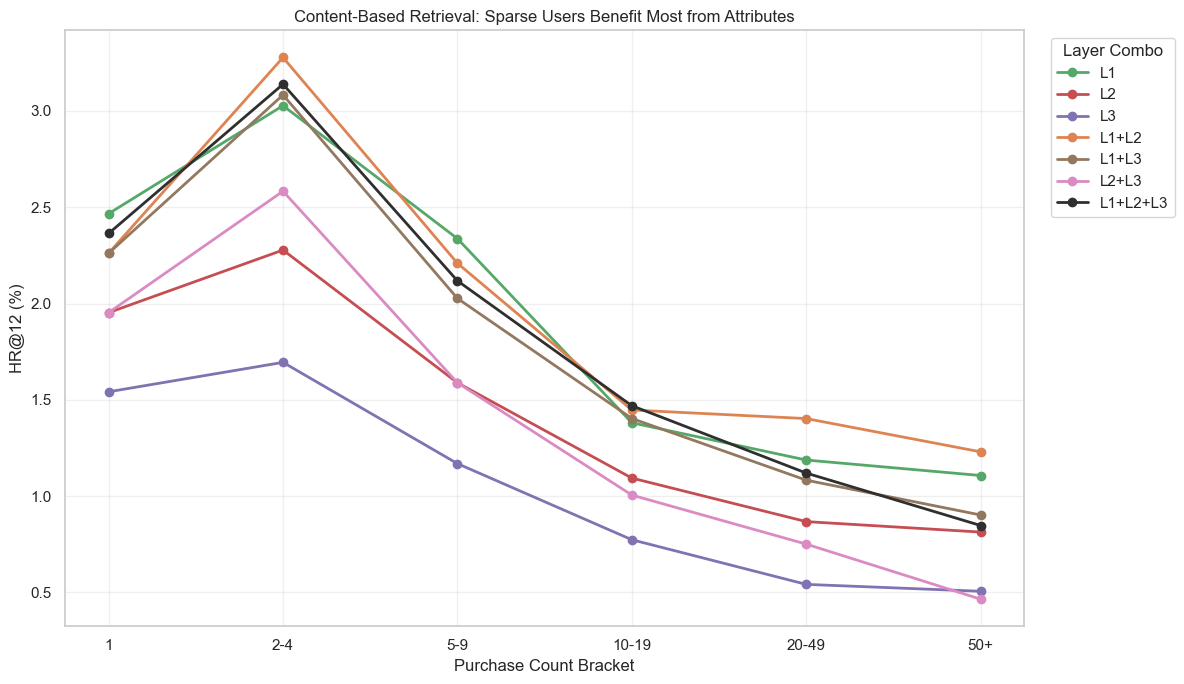

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

for combo in combo_order:
    values = pivot_hr[combo].values * 100
    ax.plot(range(len(bracket_order)), values,
            marker='o', linewidth=2, markersize=6,
            color=COMBO_COLORS[combo], label=combo)

ax.set_xticks(range(len(bracket_order)))
ax.set_xticklabels(bracket_order)
ax.set_xlabel('Purchase Count Bracket')
ax.set_ylabel('HR@12 (%)')
ax.set_title('Content-Based Retrieval: Sparse Users Benefit Most from Attributes')
ax.legend(title='Layer Combo', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '05b_cold_start_hr_by_bracket.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Observation

- **Sparse 유저(1-4건)에서 HR이 가장 높음** → 구매 이력이 적을수록 content-based가 더 유효
- **Heavy 유저(50+)에서 HR이 최저** → 다양한 구매 이력이 centroid를 희석시킴
- 이는 Triple-Sparsity 환경에서 content-based 속성의 가치를 직접 증명

## Part B: Layer 조합 효과 분석

L1 vs L1+L2 vs L1+L2+L3 주요 3종 비교 + Layer 추가 delta.

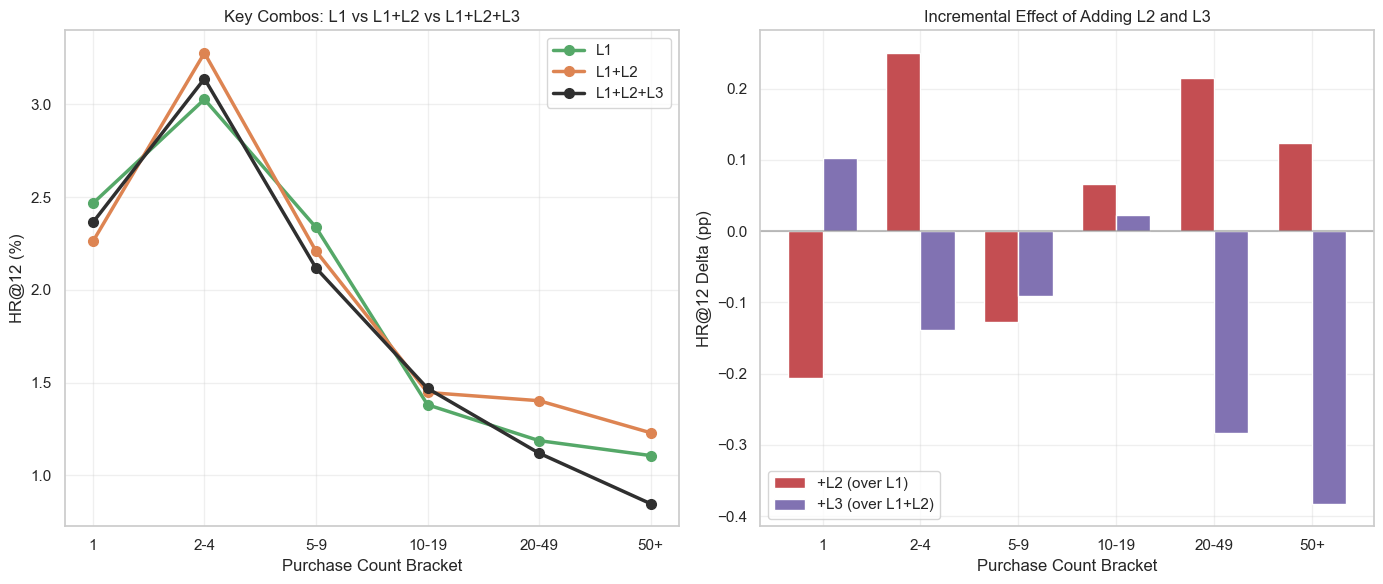

In [5]:
# Key combos comparison
key_combos = ['L1', 'L1+L2', 'L1+L2+L3']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Absolute HR@12
for combo in key_combos:
    values = pivot_hr[combo].values * 100
    axes[0].plot(range(len(bracket_order)), values,
                marker='o', linewidth=2.5, markersize=7,
                color=COMBO_COLORS[combo], label=combo)
axes[0].set_xticks(range(len(bracket_order)))
axes[0].set_xticklabels(bracket_order)
axes[0].set_xlabel('Purchase Count Bracket')
axes[0].set_ylabel('HR@12 (%)')
axes[0].set_title('Key Combos: L1 vs L1+L2 vs L1+L2+L3')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Delta: L1+L2 vs L1
delta_l2 = (pivot_hr['L1+L2'] - pivot_hr['L1']) * 100
delta_l3 = (pivot_hr['L1+L2+L3'] - pivot_hr['L1+L2']) * 100
x = np.arange(len(bracket_order))
w = 0.35
axes[1].bar(x - w/2, delta_l2, w, label='+L2 (over L1)', color='#C44E52')
axes[1].bar(x + w/2, delta_l3, w, label='+L3 (over L1+L2)', color='#8172B2')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bracket_order)
axes[1].set_xlabel('Purchase Count Bracket')
axes[1].set_ylabel('HR@12 Delta (pp)')
axes[1].set_title('Incremental Effect of Adding L2 and L3')
axes[1].legend()
axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '05b_layer_effect_delta.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Summary table
print('=== Layer Effect Summary ===')
for bracket in bracket_order:
    l1 = pivot_hr.loc[bracket, 'L1'] * 100
    l12 = pivot_hr.loc[bracket, 'L1+L2'] * 100
    l123 = pivot_hr.loc[bracket, 'L1+L2+L3'] * 100
    print(f"  [{bracket:>5s}] L1={l1:.2f}%  L1+L2={l12:.2f}% ({l12-l1:+.2f})  "
          f"L1+L2+L3={l123:.2f}% ({l123-l12:+.2f})")

=== Layer Effect Summary ===
  [    1] L1=2.47%  L1+L2=2.26% (-0.21)  L1+L2+L3=2.36% (+0.10)
  [  2-4] L1=3.03%  L1+L2=3.28% (+0.25)  L1+L2+L3=3.14% (-0.14)
  [  5-9] L1=2.34%  L1+L2=2.21% (-0.13)  L1+L2+L3=2.12% (-0.09)
  [10-19] L1=1.38%  L1+L2=1.45% (+0.07)  L1+L2+L3=1.47% (+0.02)
  [20-49] L1=1.19%  L1+L2=1.40% (+0.22)  L1+L2+L3=1.12% (-0.28)
  [  50+] L1=1.11%  L1+L2=1.23% (+0.12)  L1+L2+L3=0.85% (-0.38)


## Part C: Triple-Sparsity 결론

### 핵심 발견

1. **Content-based retrieval은 Sparse 유저에서 가장 유효** — HR@12가 1건(2.5%) > 50+건(1.1%)
2. **L1(제품 속성)이 가장 강한 단독 시그널** — 소재, 핏, 실루엣 등 물리적 속성이 구매 패턴과 직접 연결
3. **L1+L2 조합이 2-4건 구간에서 최고 (3.28%)** — 체감 속성(스타일, 분위기)이 보완재로 작동
4. **L2/L3 단독은 약함** — 체감/이론 속성만으로는 불충분, L1과의 조합에서 시너지

### Phase 5 연결

- Content-based retrieval HR@12는 KAR 모델의 **최소 기대 바닥값**
- KAR Expert의 non-linear 변환 + Gating이 이 바닥값을 얼마나 넘는지가 핵심
- L1+L2 조합이 strong baseline → Phase 5에서 L1+L2+L3가 추가 개선하는지 검증
- **Sparse 유저 분석은 별도 report** — Phase 5의 Cold-start 실험과 직접 비교 가능